# Fig 2: TTFT vs Input Length (Cached vs Uncached)

**Output:** `paper/figures/section3/output/300W/prefill_linearity.{pdf,png}`, `prefill_with_cache.{pdf,png}`

### Call order
1. `profiling/launch_prefill_profile.sh` — collect cold-prefill data (~30-60 min, GPUs 1-3)
2. `profiling/run_cache_cost.py` — collect cache-hit/miss data
3. `scripts/plot_cache_cost.py` — parse cache data → `cache_cost_table.csv`
4. `scripts/plot_prefill_linearity.py` — cold-prefill scatter + quadratic fit
5. `scripts/plot_prefill_with_cache.py` — overlays cache-hit curve

Steps 1–2 collect raw data and only need to be run once. If data is available from another machine, copy `prefill_profile_data/` and `cache_cost_data/` into `paper/figures/section3/output/300W/` and skip the collect cell below.

In [3]:
import subprocess
from pathlib import Path

REPO_ROOT = next(
    p for p in [Path.cwd()] + list(Path.cwd().parents)
    if (p / ".conserve_root").exists()
)


def run(cmd):
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    print(result.stdout, end="")
    if result.returncode != 0:
        raise RuntimeError(f"Command failed (exit {result.returncode}): {' '.join(str(c) for c in cmd)}")

In [ ]:
# Steps 1-2: collect raw profiling data. Skip if data already exists.
run(["bash", str(REPO_ROOT / "profiling/launch_prefill_profile.sh")])
run(["python", str(REPO_ROOT / "profiling/run_cache_cost.py")])

    L  miss_p50  miss_mean  miss_std  hit_p50  hit_mean  hit_std  n
  128    20.178    21.5888  6.599451   18.490   17.4954 2.332758  5
  256    14.715    14.6636  0.107818   13.286   13.2858 0.152191  5
  512    14.686    14.9188  0.498157   13.441   13.8568 1.044849  5
 1024    19.959    20.0118  0.080136   13.465   13.6748 0.527190  5
 2048    37.303    37.3112  0.187501   13.492   13.5298 0.168344  5
 4096    81.640    81.3232  0.541603   19.510   17.3708 3.135660  5
 6144   132.233   132.2018  0.232844   14.395   14.6846 0.578270  5
 8192   194.919   194.8312  0.403387   14.866   15.1146 0.608540  5
10240   263.176   263.0516  0.449812   15.117   15.2540 0.263524  5
12288   350.979   351.0050  0.594113   17.185   17.3270 0.241498  5
16384   564.915   564.1394  2.021083   21.058   21.1598 0.279680  5
20480   821.947   821.3270  2.303567   24.807   24.8568 0.176511  5
24576  1134.343  1134.1148  4.628386   28.690   28.8586 0.478993  5
28672  1478.287  1478.6370  1.347473   32.337   

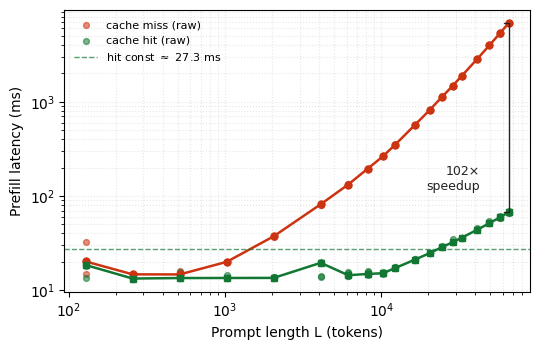

    L  n     mean_ms  median_ms     p25_ms     p75_ms     p99_ms    std_ms
  128 98   13.415755    13.1465   13.05975   13.52800   15.65099  0.593759
  256 98   13.341000    13.2680   13.18800   13.45450   14.33960  0.254726
  512 98   13.177439    13.1470   13.10325   13.22200   13.70197  0.124216
 1024 98   18.934439    18.9110   18.89375   18.93950   19.31918  0.079076
 2048 98   36.901327    36.8680   36.73375   37.05050   37.45467  0.197854
 4096 98   81.164010    81.1110   80.99375   81.27200   82.33316  0.282530
 6144 98  135.762857   135.7235  135.57625  135.88000  136.57732  0.301804
 8192 98  198.803969   198.7905  198.56675  199.04275  199.96575  0.468006
10240 98  270.230286   270.1390  269.78400  270.57775  271.64960  0.582809
12288 98  359.941010   360.0800  359.23950  360.51975  362.00766  1.010881
16384 98  587.404398   587.3430  586.25800  589.08675  591.04579  1.959182
20480 98  841.010490   841.0760  839.08025  842.94750  845.97241  2.880575
24576 98 1164.438255  116

<Figure size 640x480 with 0 Axes>

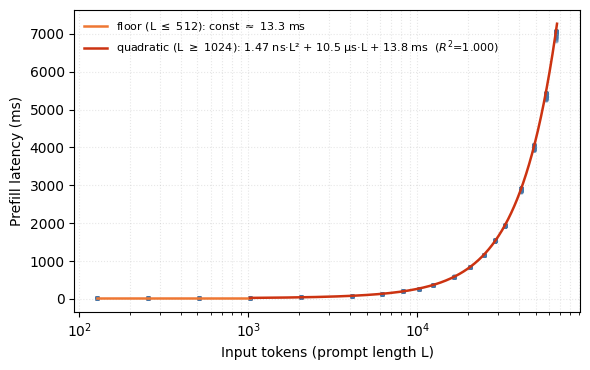

Cache-miss sanity check (cache_cost medians vs prefill_profile quadratic):
     L   cache_cost   quad_pred   profile_med   cc_resid
   128        20.18       15.20         13.15      +4.97
   256        14.71       16.62         13.27      -1.90
   512        14.69       19.58         13.15      -4.90
  1024        19.96       26.09         18.91      -6.13
  2048        37.30       41.42         36.87      -4.12
  4096        81.64       81.30         81.11      +0.34
  6144       132.23      133.48        135.72      -1.25
  8192       194.92      197.97        198.79      -3.05
 10240       263.18      274.75        270.14     -11.58
 12288       350.98      363.84        360.08     -12.86
 16384       564.91      578.92        587.34     -14.00
 20480       821.95      843.20        841.08     -21.26
 24576      1134.34     1156.70       1164.12     -22.35
 28672      1478.29     1519.39       1547.00     -41.11
 32768      1883.71     1931.30       1948.73     -47.59
 40960      2

<Figure size 640x480 with 0 Axes>

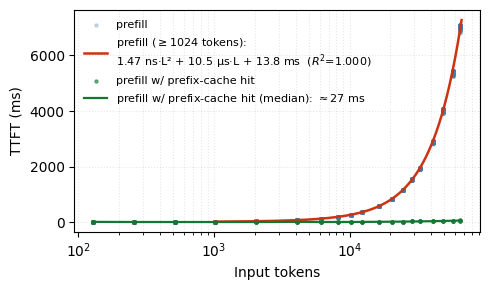

<Figure size 640x480 with 0 Axes>

In [4]:
# Steps 3-5: plot
%matplotlib inline
%run ../scripts/plot_cache_cost.py
%run ../scripts/plot_prefill_linearity.py
%run ../scripts/plot_prefill_with_cache.py

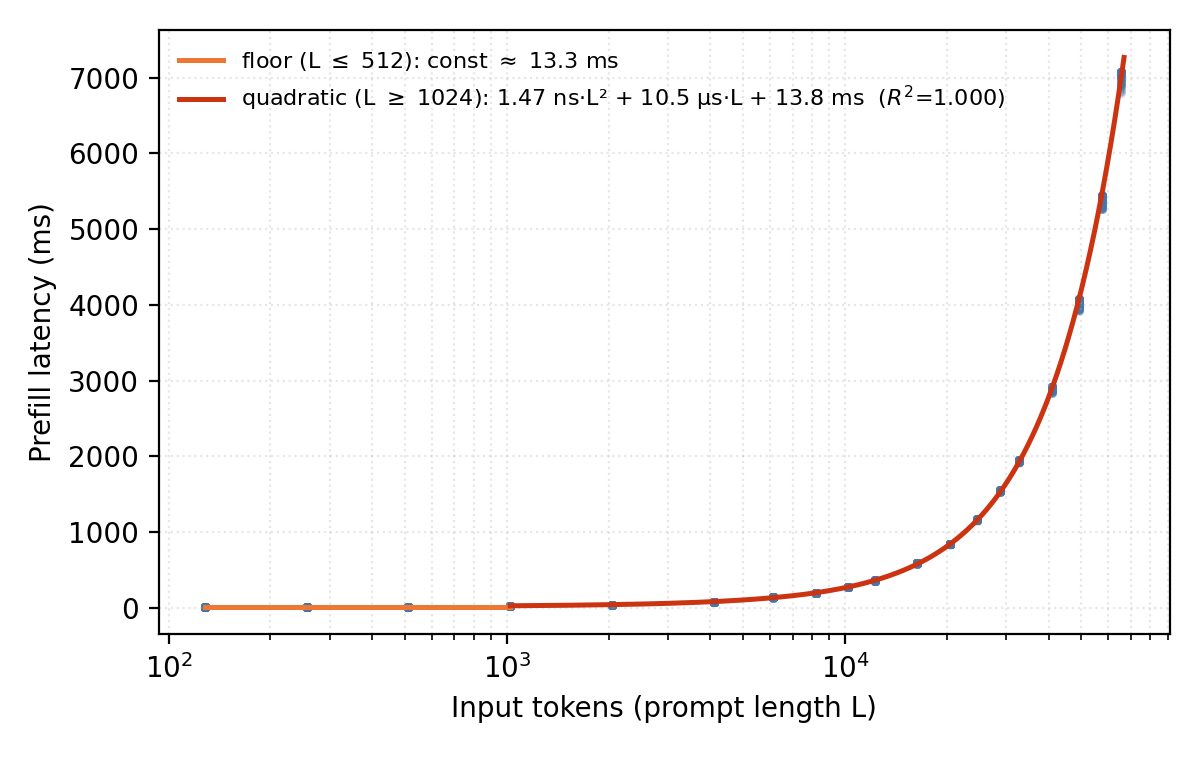

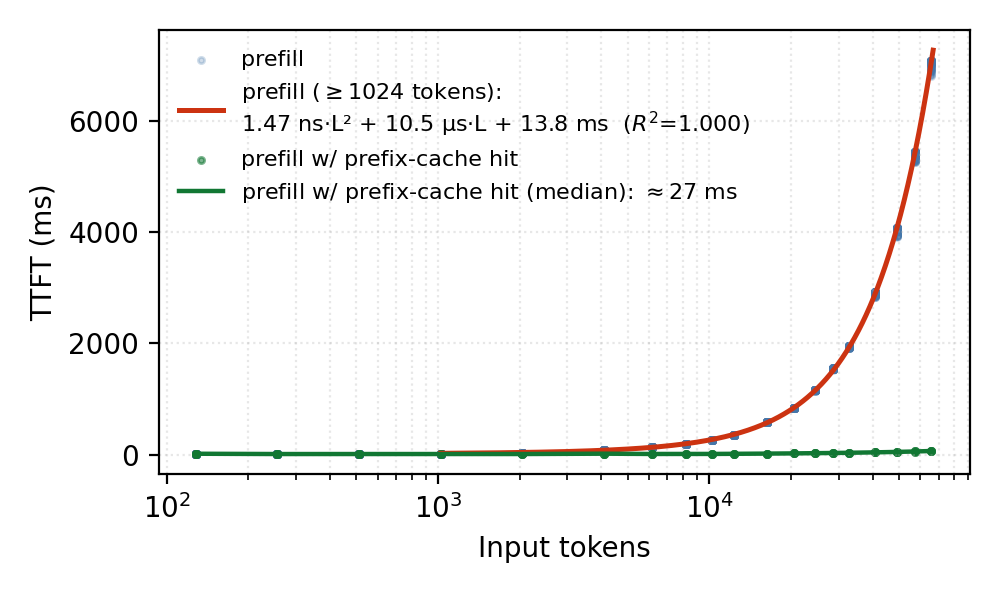

In [5]:
from IPython.display import Image, display
from pathlib import Path

out = REPO_ROOT / "paper/figures/section3/output/300W"
display(Image(str(out / "prefill_linearity.png")))
display(Image(str(out / "prefill_with_cache.png")))